<a id="top"></a>
# Chapter 4 — Filamentary switching: Stanford–PKU and Yakopcic

**MemrisTec Compact Models — Memristor Physics from Paper to Code** · chapter 4 of 6

[◀ 3 Threshold switching: VTEAM](Memristec_03_Threshold_Switching_VTEAM.ipynb) · [Contents of the book](README.md) · [5 Pulses, retention and neuromorphic use ▶](Memristec_05_Pulses_and_Neuromorphic_Use.ipynb)

**In this chapter**

- [§13 Filamentary switching and the Stanford–PKU model](#sec-13)
- [§14 Self-heating and rate dependence](#sec-14)
- [§15 The Yakopcic generalised device model](#sec-15)
- [§16 Three families on one drive](#sec-16)

All chapters: [0](Memristec_00_Introduction.ipynb) · [1](Memristec_01_State_Controlled_Resistor.ipynb) · [2](Memristec_02_Linear_Ion_Drift_and_Windows.ipynb) · [3](Memristec_03_Threshold_Switching_VTEAM.ipynb) · [4](Memristec_04_Filamentary_Switching.ipynb) · [5](Memristec_05_Pulses_and_Neuromorphic_Use.ipynb) · [6](Memristec_06_Benchmarking_and_the_Library.ipynb)

*Every notebook runs on its own: the setup cell below is identical in all of them. Section numbers (§1–26), figure numbers and cross-references are global to the book.*

In [1]:
# ---- shared setup: this cell is identical in every chapter of the book ----------
import os
import sys
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# the toolkit lives in scripts/ at the repository root (chapters/ is one level down)
for _cand in ("scripts", os.path.join("..", "scripts")):
    if os.path.isfile(os.path.join(_cand, "memristec_tools.py")):
        sys.path.insert(0, os.path.abspath(_cand))
        break
import memristec_tools as mt
from memristec_tools import (LinearIonDrift, Yakopcic2013, VTEAM2015, StanfordPKU2016, MODELS,
                             simulate, iv_sweep, loop_metrics, dynamic_route_map,
                             pulse_train, pulse_response, sine, triangular, rectangular)

plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (7.0, 4.0), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})
warnings.filterwarnings("ignore", category=RuntimeWarning)

_CHECKS = {"pass": 0, "fail": 0}
_FIG = {"n": 13}               # figure numbers run through the whole book

def check(label, ok, detail=""):
    '''Inline physics check; prints PASS/FAIL and tallies for the final summary.'''
    ok = bool(ok)
    _CHECKS["pass" if ok else "fail"] += 1
    print(f"[{'PASS' if ok else 'FAIL'}] {label}" + (f" — {detail}" if detail else ""))
    return ok

def caption(text):
    '''Numbered caption rendered directly below the figure it describes.'''
    _FIG["n"] += 1
    display(HTML(
        f"<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        f"color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        f"<b>Figure {_FIG['n']}.</b> {text}</div>"))

def show(fig):
    '''Display a figure and close it (keeps the notebook small).'''
    plt.show()
    plt.close(fig)

print("memristec-skill", mt.__version__, "| numpy", np.__version__, "| chapter 4")
t_chapter_start = time.time()

memristec-skill 0.2.0 | numpy 2.5.2 | chapter 4


<a id="sec-13"></a>

## 13. Filamentary switching and the Stanford–PKU model

In valence-change (VCM) oxides such as HfO$_x$ or TaO$_x$ the resistance is set by a conductive
filament of oxygen vacancies that almost bridges the electrodes; what remains is a **tunnelling
gap** $g$ of a few ångström to a nanometre. Jiang et al. (2016) model the device with that gap
as the state:

$$
i = I_0\, e^{-g/g_0}\, \sinh\!\frac{v}{V_0}, \qquad
\frac{dg}{dt} = -\nu_0\, e^{-E_a/kT}\, \sinh\!\Big(\gamma\,\frac{a_0}{t_{\rm ox}}\,\frac{q v}{kT}\Big), \qquad
\gamma = \gamma_0 - \beta\,(g/1\,{\rm nm})^3, \qquad
T = T_0 + |v\, i|\, R_{\rm th}.
$$

A positive voltage pulls vacancies into the gap and closes it (SET); a negative one re-opens it
(RESET). The Joule term raises the local temperature, which accelerates the ion motion
exponentially — in the paper's devices this is the positive feedback that makes SET abrupt.
(With the teaching parameter set used here the current before SET is too small to heat the
filament, so the abruptness comes from the sinh field term alone and the heating follows the
switch — exercise 4.1 measures this.) We use $x = (g_{\max} - g)/(g_{\max}
- g_{\min})$ so that $x = 1$ is the smallest gap (low resistance), as in chapters 1–2. Our
defaults are the paper's physical constants as recalled plus our own $I_0$, $g_{\min}$,
$g_{\max}$ (`references/models.md`); the equation set is checked in numbers against the
library's `Stanford_PKU` folder in chapter 6.

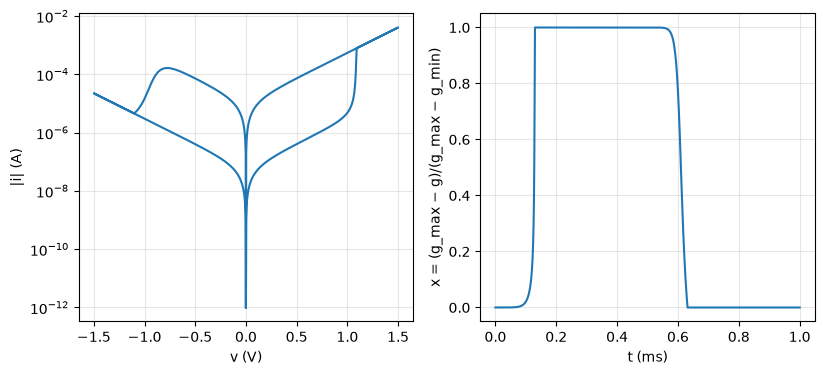

V_set = 1.079 V, V_reset = -0.954 V, HRS = 2.19e+06 Ω, LRS = 1.21e+04 Ω at 0.1 V
[PASS] SET between 0.9 and 1.3 V at 1 kHz — 1.079 V
[PASS] full SET on the positive branch, full RESET on the negative one
[PASS] HRS/LRS at 0.1 V exceeds 100 — 181
[PASS] the loop is pinched


True

In [2]:
m = StanfordPKU2016()
n = 20000                                                     # a stiff model: 20 000 points per period
res = iv_sweep(m, 1.5, 1e3, cycles=1, n_per_cycle=n)
q = n // 4
v_set = res.v[int(np.argmax(res.x[:q] > 0.5))]
v_reset = res.v[2 * q + int(np.argmax(res.x[2 * q:3 * q] < 0.5))]
hrs, lrs = 0.1 / m.current(0.0, 0.1), 0.1 / m.current(1.0, 0.1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4.0))
ax1.semilogy(res.v[::5], np.abs(res.i[::5]) + 1e-12); ax1.set_xlabel("v (V)"); ax1.set_ylabel("|i| (A)")
ax2.plot(res.t[::5] * 1e3, res.x[::5]); ax2.set_xlabel("t (ms)"); ax2.set_ylabel("x = (g_max − g)/(g_max − g_min)")
show(fig)
caption("Stanford–PKU model under a 1.5 V, 1 kHz sine. Left: |i| against v on a log scale — an "
        "abrupt SET near +1.1 V on the rising branch and a gradual RESET on the negative branch. "
        "Right: the normalised gap state closing (x → 1) and re-opening (x → 0) within one period.")
print(f"V_set = {v_set:.3f} V, V_reset = {v_reset:.3f} V, HRS = {hrs:.3g} Ω, LRS = {lrs:.3g} Ω at 0.1 V")
check("SET between 0.9 and 1.3 V at 1 kHz", 0.9 < v_set < 1.3, f"{v_set:.3f} V")
check("full SET on the positive branch, full RESET on the negative one", res.x[q] == 1.0 and res.x[3 * q] == 0.0 and res.x[-1] == 0.0)
check("HRS/LRS at 0.1 V exceeds 100", hrs / lrs > 100, f"{hrs / lrs:.0f}")
check("the loop is pinched", loop_metrics(res)["pinched_at_origin"])

<a id="sec-14"></a>

## 14. Self-heating and rate dependence

Two consequences of the thermally activated rate: the filament heats up during SET, and the
SET voltage depends on how fast the voltage is ramped — a slow sweep gives the ions time to
move at a lower voltage, a fast sweep needs a larger overdrive. Both are measured
fingerprints of filamentary devices, and both fall out of the four equations above.

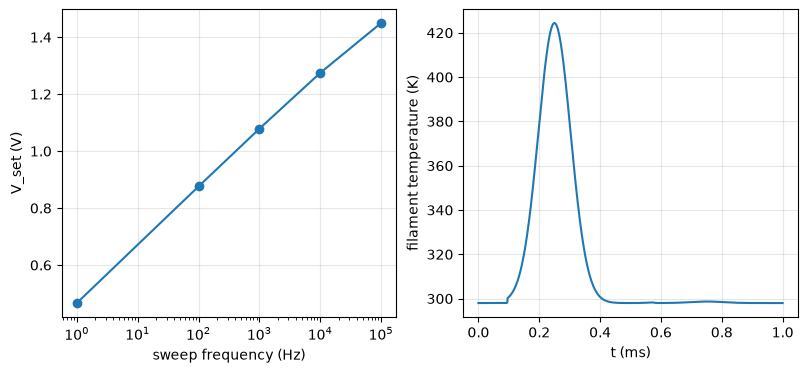

[PASS] V_set increases monotonically with frequency — 0.47, 0.88, 1.08, 1.27, 1.45 V
[PASS] V_set(1 Hz) is below 0.6 V and V_set(100 kHz) above 1.3 V
[PASS] the filament heats by more than 50 K at 2 V — T_max = 424 K


True

In [3]:
def v_set_at(freq, amplitude=1.5, n=20000):
    r = iv_sweep(StanfordPKU2016(), amplitude, freq, cycles=1, n_per_cycle=n)
    return r.v[int(np.argmax(r.x[:n // 4] > 0.5))]

freqs = [1.0, 1e2, 1e3, 1e4, 1e5]
vsets = [v_set_at(f) for f in freqs]
m = StanfordPKU2016()
r2 = iv_sweep(m, 2.0, 1e3, cycles=1, n_per_cycle=20000)
T = np.array([m.temperature(x, v) for x, v in zip(r2.x, r2.v)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4.0))
ax1.semilogx(freqs, vsets, "o-"); ax1.set_xlabel("sweep frequency (Hz)"); ax1.set_ylabel("V_set (V)")
ax2.plot(r2.t[::5] * 1e3, T[::5]); ax2.set_xlabel("t (ms)"); ax2.set_ylabel("filament temperature (K)")
show(fig)
caption("Left: the SET voltage rises with the sweep rate (1 Hz to 100 kHz, 1.5 V sine). Right: the "
        "filament temperature during a 2 V, 1 kHz sweep — a Joule spike of about a hundred kelvin "
        "at SET, when the current jumps while the voltage is still high.")
check("V_set increases monotonically with frequency", all(a < b for a, b in zip(vsets, vsets[1:])),
      ", ".join(f"{v:.2f}" for v in vsets) + " V")
check("V_set(1 Hz) is below 0.6 V and V_set(100 kHz) above 1.3 V", vsets[0] < 0.6 and vsets[-1] > 1.3)
check("the filament heats by more than 50 K at 2 V", T.max() - m.params["T0"] > 50, f"T_max = {T.max():.0f} K")

<a id="sec-15"></a>

## 15. The Yakopcic generalised device model

Yakopcic et al. (2011, 2013) wrote a model general enough to fit several published devices
with one equation set: a sinh current law with a state-proportional prefactor, a voltage
threshold $g(v)$ that is exactly zero inside $[-V_n, V_p]$ and exponential outside, and a
boundary function $f(x, v)$ that slows the motion near the ends,

$$
i = a_{1,2}\, x\, \sinh(b v), \qquad
\dot x = \eta\, g(v)\, f(x, v), \qquad
g(v) = \begin{cases} A_p\,(e^{v} - e^{V_p}) & v > V_p \\ -A_n\,(e^{-v} - e^{V_n}) & v < -V_n \\ 0 & \text{otherwise.}\end{cases}
$$

Unlike VTEAM its current is not ohmic in the state ($i \propto x\sinh bv$: at $x = 0$ the
device is an open circuit), and its DRM shows both the dead band and the exponential boundary
decay. The default parameters are the 2013 paper's example device; the library's `Yakopcic2013`
folder hard-codes the same set, and chapter 6 cross-checks the two derivative fields.

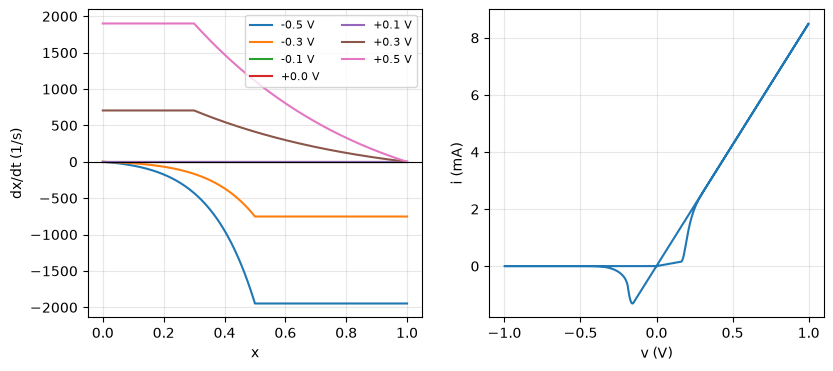

[PASS] dead band: no motion for -Vn ≤ v ≤ Vp
[PASS] boundary functions vanish at the ends
[PASS] the loop is pinched and the device switches to x > 0.999 (x = 1 is an asymptote: wp(1) = 0) — x_max = 1.000000
[PASS] current is proportional to x: i(x=0) = 0


True

In [4]:
y = Yakopcic2013()
xs = np.linspace(0.0, 1.0, 201)
drm = dynamic_route_map(y, xs, [-0.5, -0.3, -0.1, 0.0, 0.1, 0.3, 0.5])
res = iv_sweep(y, 1.0, 1.0, cycles=1, n_per_cycle=4000)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4.0))
for v, rate in drm.items():
    ax1.plot(xs, rate, label=f"{v:+.1f} V")
ax1.axhline(0, color="k", lw=0.8); ax1.set_xlabel("x"); ax1.set_ylabel("dx/dt (1/s)"); ax1.legend(fontsize=8, ncol=2)
ax2.plot(res.v, 1e3 * res.i); ax2.set_xlabel("v (V)"); ax2.set_ylabel("i (mA)")
show(fig)
caption("Yakopcic 2013 example device. Left: dynamic route map — zero rate inside the dead band "
        "(−0.15 V ≤ v ≤ 0.16 V), an exponential slow-down beyond x_p = 0.3 for positive and below "
        "1 − x_n = 0.5 for negative voltages, zero at the boundaries. Right: the pinched loop under "
        "a 1 V, 1 Hz sine.")
check("dead band: no motion for -Vn ≤ v ≤ Vp", all(np.all(drm[v] == 0.0) for v in (-0.1, 0.0, 0.1)))
check("boundary functions vanish at the ends", drm[0.5][-1] == 0.0 and drm[-0.5][0] == 0.0)
check("the loop is pinched and the device switches to x > 0.999 (x = 1 is an asymptote: wp(1) = 0)",
      loop_metrics(res)["pinched_at_origin"] and res.x.max() > 0.999, f"x_max = {res.x.max():.6f}")
check("current is proportional to x: i(x=0) = 0", y.current(0.0, 0.5) == 0.0 and y.current(1.0, 0.5) == 2 * y.current(0.5, 0.5))

<a id="sec-16"></a>

## 16. Three families on one drive

Drift, threshold and filament respond very differently to the same 1.5 V, 1 Hz sine: the
linear ion drift model moves a little and smoothly, VTEAM switches between two fixed
resistances with a dead band, the Stanford–PKU model snaps from a megaohm to kiloohms. The
figure plots the read conductance (at 0.1 V) along the sweep on a log scale; the on/off ratio
reached is the number that decides whether a device is a memory.

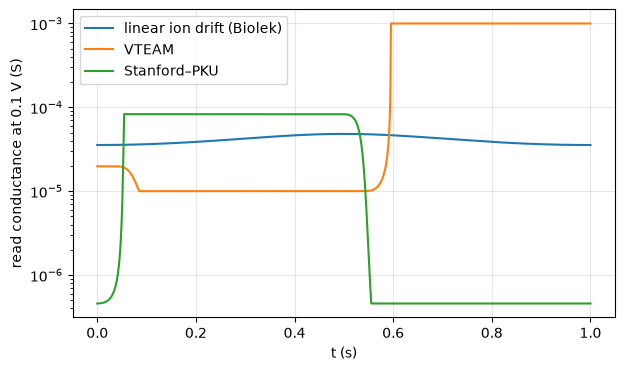

[PASS] on/off ratios rank filament > threshold > drift — linear ion drift (Biolek): 1.36, VTEAM: 100, Stanford–PKU: 181
[PASS] VTEAM's ratio is R_off/R_on = 100


True

In [5]:
drive = dict(amplitude=1.5, frequency=1.0, cycles=1)
models = {"linear ion drift (Biolek)": (LinearIonDrift(window="biolek", R_off=38e3, x0=0.26), 4000),
          "VTEAM": (VTEAM2015(), 4000), "Stanford–PKU": (StanfordPKU2016(), 20000)}
fig, ax = plt.subplots()
ratios = {}
for name, (m, n) in models.items():
    r = iv_sweep(m, drive["amplitude"], drive["frequency"], cycles=drive["cycles"], n_per_cycle=n)
    G = np.array([m.current(x, 0.1) / 0.1 for x in r.x[::max(1, n // 2000)]])
    ratios[name] = G.max() / G.min()
    ax.semilogy(r.t[::max(1, n // 2000)], G, label=name)
ax.set_xlabel("t (s)"); ax.set_ylabel("read conductance at 0.1 V (S)"); ax.legend()
show(fig)
caption("Read conductance along one 1.5 V, 1 Hz sine for the three model families: a smooth "
        "excursion of ~30 % for linear ion drift, a factor 100 for VTEAM, more than two orders "
        "of magnitude for the filamentary model.")
check("on/off ratios rank filament > threshold > drift", ratios["Stanford–PKU"] > ratios["VTEAM"] > ratios["linear ion drift (Biolek)"],
      ", ".join(f"{k}: {v:.3g}" for k, v in ratios.items()))
check("VTEAM's ratio is R_off/R_on = 100", np.isclose(ratios["VTEAM"], 100.0, rtol=1e-3))

### Exercises for chapter 4

**4.1** Switch the thermal feedback off (`R_th=0`) in the Stanford–PKU model. Does the SET
voltage at 1 kHz change? Where in the sweep does the temperature actually peak, and why can
the heating not act on the state there?

**4.2** Yakopcic's $\eta$ flips the direction of the state motion relative to the voltage.
Show that $\eta = -1$ mirrors the loop of §15.

In [6]:
# 4.1 — measured, not assumed: with I0 = 0.1 mA the HRS current before SET dissipates microwatts,
#       so T stays within 0.1 K of T0 until the gap has closed; V_set(cold) equals V_set(hot) to
#       better than 1 mV (1.0785 V both), and so does V_reset (−0.954 vs −0.955 V). The 2 V sweep
#       of §14 peaks at 424 K only after SET, when x = 1 and the clip leaves nothing to switch.
n = 20000
r_cold = iv_sweep(StanfordPKU2016(R_th=0.0), 1.5, 1e3, cycles=1, n_per_cycle=n)
v_cold = r_cold.v[int(np.argmax(r_cold.x[:n // 4] > 0.5))] if (r_cold.x[:n // 4] > 0.5).any() else np.inf
check("4.1 without thermal feedback V_set at 1 kHz is unchanged to 1 mV", abs(v_cold - v_set_at(1e3)) < 1e-3,
      f"V_set(cold) = {v_cold:.4f} V, V_set(hot) = {v_set_at(1e3):.4f} V")
check("4.1 the temperature peak of the 2 V sweep occurs while x = 1 (after SET)", r2.x[int(np.argmax(T))] == 1.0,
      f"T_max = {T.max():.0f} K at t = {r2.t[int(np.argmax(T))] * 1e3:.3f} ms")

# 4.2 — eta = -1: the state moves the other way, the loop is the point reflection of the original
r_p = iv_sweep(Yakopcic2013(eta=1), 1.0, 1.0, cycles=1, n_per_cycle=4000)
r_m = iv_sweep(Yakopcic2013(eta=-1), 1.0, 1.0, cycles=1, n_per_cycle=4000)
check("4.2 eta = -1 drives x down where eta = +1 drives it up", r_m.x[1000] < r_m.x[0] and r_p.x[1000] > r_p.x[0])

[PASS] 4.1 without thermal feedback V_set at 1 kHz is unchanged to 1 mV — V_set(cold) = 1.0785 V, V_set(hot) = 1.0785 V
[PASS] 4.1 the temperature peak of the 2 V sweep occurs while x = 1 (after SET) — T_max = 424 K at t = 0.250 ms
[PASS] 4.2 eta = -1 drives x down where eta = +1 drives it up


True

In [7]:
# ---- tally for this notebook ---------------------------------------------------
print("=" * 66)
print(f"chapter 4 — checks passed : {_CHECKS['pass']}")
print(f"chapter 4 — checks failed : {_CHECKS['fail']}")
print(f"wall time                 : {time.time() - t_chapter_start:.0f} s")
print("=" * 66)
print("Every quantitative claim in this notebook was verified in this run."
      if _CHECKS["fail"] == 0 else "Some checks FAILED — search this notebook for '[FAIL]'.")

chapter 4 — checks passed : 16
chapter 4 — checks failed : 0
wall time                 : 12 s
Every quantitative claim in this notebook was verified in this run.
